In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Carica i dati
df = pd.read_csv(r'C:\Users\david\OneDrive - Università degli Studi di Parma\PhD\Projects\Coffee_leaf_infuses\data\processed\others\keyodorants.csv')

# Estrai il tipo di campione (H o C) dalla colonna Samples
df['temperature_type'] = df['Samples'].str.extract(r'([HC])')[0]

# Trasforma il dataframe da wide a long format
df_long = df.melt(id_vars=['Samples', 'temperature_type'], 
                   var_name='Compounds', 
                   value_name='Intensity')

# Trasforma in scala logaritmica
df_long['Intensity'] = df_long['Intensity'].replace(0, np.nan)
df_long['Intensity_log'] = np.log10(df_long['Intensity'])

# OPZIONE 2: Heatmap delle medie per ogni composto
df_pivot = df_long.groupby(['Compounds', 'temperature_type'])['Intensity_log'].mean().unstack()
plt.figure(figsize=(12, 4))
sns.heatmap(df_pivot.T, annot=True, fmt='.1f', cmap='vlag', cbar_kws={'label': 'log10(Intensità)'})
plt.title('Average intensity of key odorants compounds: Hot vs. Cold', fontsize=14)
plt.tight_layout()
plt.show()



KeyError: "'vl' is not a known colormap name"

: 

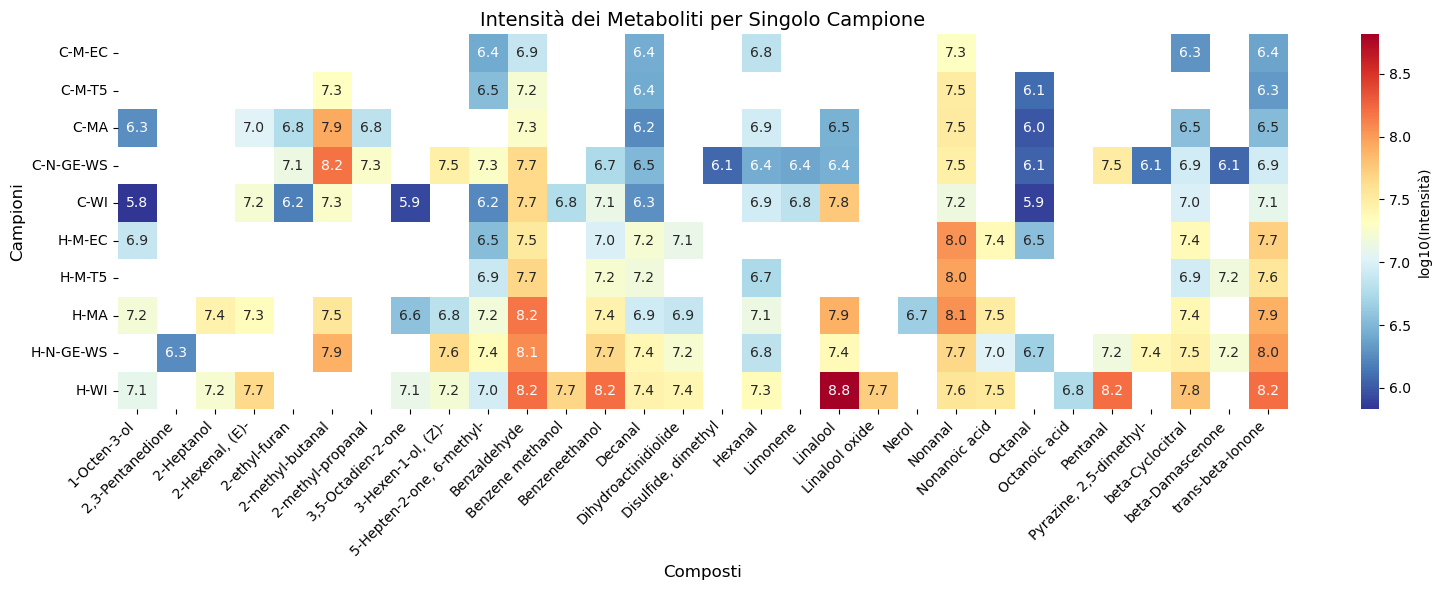

In [ ]:
# ...existing code...

# OPZIONE 2 MIGLIORATA: Heatmap con media dei singoli campioni
# Calcola la media per ogni campione (considerando i replicati)
df_with_temp = df.copy()
df_with_temp['temperature_type'] = df_with_temp['Samples'].str.extract(r'([HC])')[0]

# Estrai il nome del campione (senza il numero di replicato)
df_with_temp['campione_base'] = df_with_temp['Samples'].str.replace(r'_\d+$', '', regex=True)

# Trasforma in long format
df_long_complete = df_with_temp.melt(id_vars=['Samples', 'campione_base', 'temperature_type'], 
                                      var_name='composto', 
                                      value_name='intensita')

# Trasforma in scala logaritmica
df_long_complete['intensita'] = df_long_complete['intensita'].replace(0, np.nan)
df_long_complete['intensita_log'] = np.log10(df_long_complete['intensita'])

# Calcola la media per ogni campione base
df_campioni = df_long_complete.groupby(['campione_base', 'temperature_type', 'composto'])['intensita_log'].mean().reset_index()
df_pivot_campioni = df_campioni.pivot_table(index='campione_base', columns='composto', values='intensita_log')

# Crea la heatmap
plt.figure(figsize=(16, 6))
sns.heatmap(df_pivot_campioni, annot=True, fmt='.1f', cmap='RdYlBu_r', cbar_kws={'label': 'log10(Intensità)'})
plt.title('Intensità dei Metaboliti per Singolo Campione', fontsize=14)
plt.xlabel('Composti', fontsize=12)
plt.ylabel('Campioni', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()